In [1]:
import numpy as np
from PIL import Image
import matplotlib.pyplot as plt
from matplotlib import colors
import ipywidgets as widgets
from IPython.display import display
from IPython.display import clear_output  # clear_output(wait=True)
import time
import os
import sys
import h5py
import myPy_functions as my

import PyPump as pp


# Physical parameters
f0 = 4.2                       # Central resonance frequency in GHz
omega0 = 2 * np.pi * f0       # Angular frequency [rad/s]
Delta_f = 0.1e-3              # Mode spacing in GHz
Delta = 2 * np.pi * Delta_f   # Angular frequency spacing

# Loss rates
gamma_int = 0.0                              # Internal loss [GHz]
gamma_ext = 2 * np.pi * 100e6 / 1e9          # External coupling [GHz]
g1_value = 24 	                             # Reference coupling strength
gamma_over_g = 10.0                          # Dissipation-to-coupling ratio

# Compute total decay rate
gamma_r      = g1_value * gamma_over_g       # Reference decay rate
gamma0_ext   = gamma_ext * gamma_r           # Scaled external decay rate
gamma        = gamma_int + gamma0_ext        # Total decay rate

# Number of modes and size of Matrices
Nmodes=11

# Loss and Id matrices
K = np.identity(2 * Nmodes) * np.sqrt(gamma0_ext)
Id = np.eye(2*Nmodes, dtype=complex)  # Identity matrix of size 2*Nx 

# Change of basis Transformation Matrices: a,a* --U--> x,p
U_2by2= (1/np.sqrt(2))*np.array([[1,  1j],
                                 [1, -1j]])                 # \vec{a} = U\vec{x}
Udag_2by2= (1/np.sqrt(2))*np.array([[ 1,  1 ],
                                    [-1j, 1j]])             # \vec{x} = Udag\vec{a}
U=np.kron(np.eye(Nmodes,dtype=complex),U_2by2)              # nmodes is number of repeated blocks
Udag=np.linalg.inv(U) 

def S_training_gen(omega0, Delta, Nmodes, prnt=None, x=None):
    import numpy as np
    import myPy_functions as my

    # Change of basis Transformation Matrices: a,a* --U--> x,p
    U_2by2= (1/np.sqrt(2))*np.array([[1,  1j],
                                    [1, -1j]])                 # \vec{a} = U\vec{x}
    Udag_2by2= (1/np.sqrt(2))*np.array([[ 1,  1 ],
                                        [-1j, 1j]])             # \vec{x} = Udag\vec{a}
    U=np.kron(np.eye(Nmodes,dtype=complex),U_2by2)              # nmodes is number of repeated blocks
    Udag=np.linalg.inv(U) 
    gmax = 1.5 #2.0
    if ( x == None ):  # IF the selector x is not given... generate it randomly
        x=np.random.randint(0, 6, dtype=int)
    match x:
        case 0: # Single pump (p=1/6)
            Npumps = 1
            Ap_k = gmax*np.random.rand(Npumps)
            phi_k = 2*np.pi*np.random.rand(Npumps)
            gp_k = Ap_k * np.exp(1j*phi_k) 
            sq_fc_flag = np.random.randint(0, 2, Npumps,  dtype=int)
            match sq_fc_flag:
                case 0: # Freq. Conv. pump  (p=1/12)
                    k_arr = np.random.randint(1, Nmodes-1, Npumps,  dtype=int)
                case 1: # Sq. pump  (p=1/12)
                    k_arr = np.random.randint(-Nmodes+1, Nmodes-1, Npumps,  dtype=int) 
            omega_k = 2*omega0*sq_fc_flag + k_arr * Delta 
            Saa, _ = my.compute_bigS_from_g(Nmodes, gp_k, omega_k, omega0, Delta) 
        case 1: # Multiple SQ pumps (p=1/6)
            Npumps = np.random.randint(0, 2*Nmodes,  dtype=int)
            Ap_k = gmax*np.random.rand(Npumps)
            phi_k = 2*np.pi*np.random.rand(Npumps)
            gp_k = Ap_k * np.exp(1j*phi_k) 
            k_arr = np.random.randint(-Nmodes+1, Nmodes-1, Npumps,  dtype=int) 
            omega_k = 2*omega0 + k_arr * Delta 
            Saa, _ = my.compute_bigS_from_g(Nmodes, gp_k, omega_k, omega0, Delta) 
        case 2: # Multiple FC pumps (p=1/6)
            Npumps = np.random.randint(0, Nmodes,  dtype=int)
            Ap_k = gmax*np.random.rand(Npumps)
            phi_k = 2*np.pi*np.random.rand(Npumps)
            gp_k = Ap_k * np.exp(1j*phi_k) 
            k_arr = np.random.randint(1, Nmodes-1, Npumps,  dtype=int) 
            omega_k = k_arr * Delta 
            Saa, _ = my.compute_bigS_from_g(Nmodes, gp_k, omega_k, omega0, Delta) 
        case 3: # Multiple SQ and FC pumps together (p=1/6)
            # FC
            Npumps_fc = np.random.randint(0, Nmodes,  dtype=int)
            Ap_k_fc = gmax*np.random.rand(Npumps_fc)
            phi_k_fc = 2*np.pi*np.random.rand(Npumps_fc)
            gp_k_fc = Ap_k_fc * np.exp(1j*phi_k_fc) 
            k_arr_fc = np.random.randint(1, Nmodes-1, Npumps_fc,  dtype=int) 
            omega_k_fc = k_arr_fc * Delta 
            # SQ
            Npumps_sq = np.random.randint(0, 2*Nmodes,  dtype=int)
            Ap_k_sq = gmax*np.random.rand(Npumps_sq)
            phi_k_sq = 2*np.pi*np.random.rand(Npumps_sq)
            gp_k_sq = Ap_k_sq * np.exp(1j*phi_k_sq) 
            k_arr_sq = np.random.randint(-Nmodes+1, Nmodes-1, Npumps_sq,  dtype=int) 
            omega_k_sq = 2*omega0 + k_arr_sq * Delta 
            # FC + SQ
            Npumps= Npumps_fc + Npumps_sq
            gp_k = np.concatenate([gp_k_fc, gp_k_sq])
            omega_k = np.concatenate([omega_k_fc, omega_k_sq])
            Saa, _ = my.compute_bigS_from_g(Nmodes, gp_k, omega_k, omega0, Delta) 
        case _: #All pumps present, random (p=1/3)
            # FC
            Npumps_fc = Nmodes-1 
            Ap_k_fc = gmax*np.random.rand(Npumps_fc)
            phi_k_fc = 2*np.pi*np.random.rand(Npumps_fc)
            gp_k_fc = Ap_k_fc * np.exp(1j*phi_k_fc) 
            k_arr_fc = np.arange(1, Nmodes) 
            omega_k_fc = k_arr_fc * Delta 
            # SQ
            Npumps_sq = 2*Nmodes-1
            Ap_k_sq = gmax*np.random.rand(Npumps_sq)
            phi_k_sq = 2*np.pi*np.random.rand(Npumps_sq)
            gp_k_sq = Ap_k_sq * np.exp(1j*phi_k_sq) 
            k_arr_sq = np.arange(-Nmodes+1, Nmodes) 

            omega_k_sq = 2*omega0 + k_arr_sq * Delta 
            # FC + SQ
            Npumps= Npumps_fc + Npumps_sq
            gp_k = np.concatenate([gp_k_fc, gp_k_sq])
            omega_k = np.concatenate([omega_k_fc, omega_k_sq])
            Saa, _ = my.compute_bigS_from_g(Nmodes, gp_k, omega_k, omega0, Delta) 
    # Compute S in xp basis
    if (prnt != None):
        print('x= ',x)
    S = np.real((Udag.dot(Saa).dot(U)))
    return S, gp_k, omega_k

def PyPump_g_from_S(Saa,K,Id):
    Nmodes = Saa.shape[0] // 2

    # Compute M from S
    M =pp.M_reconstructed_from_S(Saa, K, Id)

    k_arr, k_arr_conv, magnitudes_Γ_plus, phases_Γ_plus, magnitudes_Γ_minus, phases_Γ_minus, magnitudes_G_plus, phases_G_plus, magnitudes_G_minus, phases_G_minus = pp.compute_pumping_scheme_Fabio(Nmodes, 24, M, 1e-15)
    gp_k_fc = magnitudes_G_plus * np.exp(1j*phases_G_plus) 
    gp_k_sq = magnitudes_Γ_plus * np.exp(1j*phases_Γ_plus) 
    omega_k_fc = k_arr_conv * Delta
    omega_k_sq = 2*omega0 + k_arr * Delta 
    gp_k = np.concatenate([gp_k_fc, gp_k_sq])
    omega_k = np.concatenate([omega_k_fc, omega_k_sq])

    return gp_k, omega_k




In [2]:
# LOAD DATA
# fname='Error_vs_N_2025-09-25_16_02.npz'  # Oldo kind of wrong  S0 (just the last), no SN_over_S0
# fname='Error_vs_N_2025-10-01_08_32.npz'  # New with SN_over_S0
fname='Error_vs_N_2025-10-01_22_56.npz'  # New range noise [10^-18 ..10^2]
data = np.load(fname)
Nvec=data['Nvec']
norm_noise=data['norm_noise']
S0_v=data['S0']         
S0_nn_v=data['S0_nn']  
S0nn_v=data['S0nn']  
SN_over_S0=data['SN_over_S0']
Sgen0_sypm_test=data['Sgen0_sypm_test']
Sgen_sypm_test=data['Sgen_sypm_test']
Srec_sypm_test=data['Srec_sypm_test']
Er_vs_N=data['Er_vs_N']
Er_vs_S=data['Er_vs_S']  
Er_vs_Nrel=data['Er_vs_Nrel']
Er_vs_Srel=data['Er_vs_Srel']
Nsize=Nvec.shape[0]

S0=np.mean(S0_v, axis=1)         
S0_nn=np.mean(S0_nn_v, axis=1)  
S0nn=np.mean(S0nn_v, axis=1) 

### Figure 2 - Benchmarching Pump Projection Method

In [3]:
# LOAD DATA STAT AVG
fname='Error_vs_N_stat2025-10-07_06_08.npz'  # New range noise [10^-18 ..10^2]
data = np.load(fname)
Nvec=data['Nvec']
norm_noise_stat=data['norm_noise_stat']
S0_stat=data['S0_stat']         
SN_over_S0_stat=data['SN_over_S0_stat']
Sgen0_sypm_test_stat=data['Sgen0_sypm_test_stat']
Sgen_sypm_test_stat=data['Sgen_sypm_test_stat']
Srec_sypm_test_stat=data['Srec_sypm_test_stat']
Er_vs_N_stat=data['Er_vs_N_stat']
Er_vs_S_stat=data['Er_vs_S_stat']  
Er_vs_Nrel_stat=data['Er_vs_Nrel_stat']
Er_vs_Srel_stat=data['Er_vs_Srel_stat']
Nsize=Nvec.shape[0]

#Comp averages and std
Er_vs_N_stat_avg = np.mean(Er_vs_N_stat, axis=2)
Er_vs_N_stat_std = np.std(Er_vs_N_stat, axis=2)
Er_vs_S_stat_avg = np.mean(Er_vs_S_stat, axis=2)
Er_vs_S_stat_std = np.std(Er_vs_S_stat, axis=2)
Er_vs_Nrel_stat_avg = np.mean(Er_vs_Nrel_stat, axis=2)
Er_vs_Nrel_stat_std = np.std(Er_vs_Nrel_stat, axis=2)
Er_vs_Srel_stat_avg = np.mean(Er_vs_Srel_stat, axis=2)
Er_vs_Srel_stat_std = np.std(Er_vs_Srel_stat, axis=2)   
S0_stat_avg = np.mean(S0_stat, axis=2)         
SN_over_S0_stat_avg = np.mean(SN_over_S0_stat, axis=2)

Nsize = Er_vs_N_stat.shape[0]
Nsample = Er_vs_N_stat.shape[1]
Nnoise = Er_vs_N_stat.shape[2]

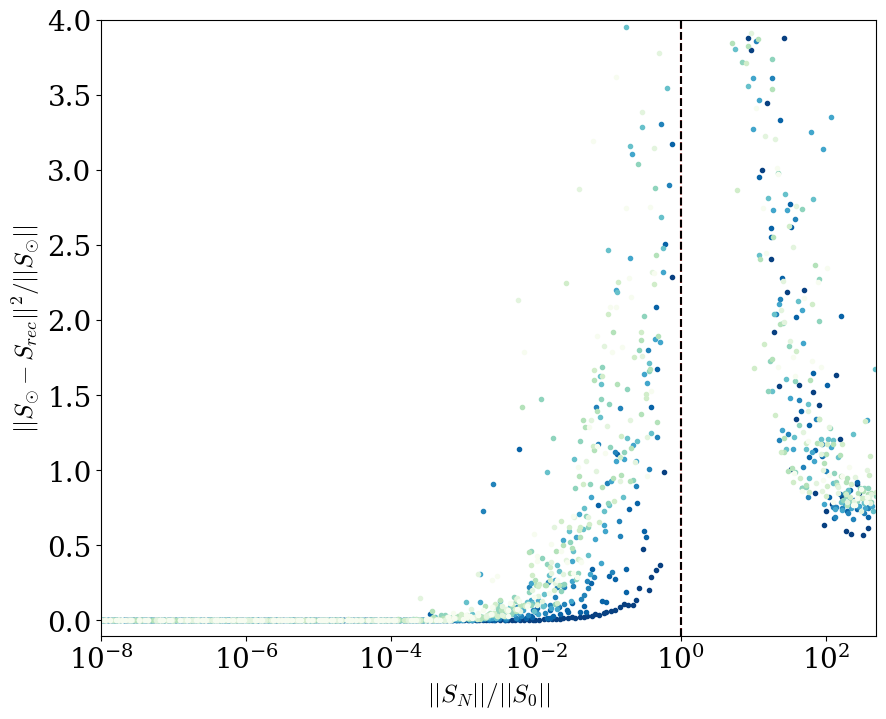

In [4]:
#Style
plt.rcParams['axes.formatter.useoffset'] = False
plt.rcParams['figure.constrained_layout.use'] = False #True
plt.rcParams['axes.labelsize'] = 18
plt.rcParams['font.size'] = 20
plt.rcParams['legend.fontsize'] = 20
plt.rcParams['legend.frameon'] = False
plt.rcParams["font.weight"] = "normal"
plt.rcParams["font.family"] = "serif"
plt.rcParams["mathtext.fontset"] = "cm"

# Colors
col_vec = plt.cm.Spectral(np.linspace(0, 1, Nsize))
col_vec = plt.cm.RdBu_r(np.linspace(0, 1, Nsize))
col_vec = plt.cm.GnBu_r(np.linspace(0, 1, Nsize))     #"GnBu_r"
lines = []
lines2=[]
labels = []


# Plot
fig2, ax2 = plt.subplots(1, 1, figsize=(10,8))

for n_md0 in range(Nsize):
    col0= col_vec[n_md0]
    pl202 = ax2.semilogx(SN_over_S0_stat_avg[n_md0, :], Er_vs_Srel_stat_avg[n_md0, :],'.', color=col0)
    
    
ax2.axvline(1, color='red', linestyle='--')

# pl201u =ax2.fill_between(SN_over_S0_stat_avg[n_md, :], 
#                   y1=Er_vs_Srel_stat_avg[n_md, :] + Er_vs_Srel_stat_std[n_md, :], 
#                   y2=np.max([Er_vs_Srel_stat_avg[n_md, :] - Er_vs_Srel_stat_std[n_md, :],np.zeros_like(Er_vs_Srel_stat_avg[n_md, :])], axis=0),
#                   edgecolor=col,
#                   facecolor=col,
#                   alpha=0.3)   
ax2.axvline(1, color='k', linestyle='--')

ax2.set_xlabel('$||S_N||/||S_0||$')
ax2.set_ylabel('$||S_{\odot} - S_{rec}||^2 / ||S_{\odot}||$')
ax2.set_ylim([-0.1,4])
ax2.set_xlim([1e-8,5e2])

lines.append(pl202)

ax2.legend(lines, labels)



plt.show()

2.220446049250313e-16


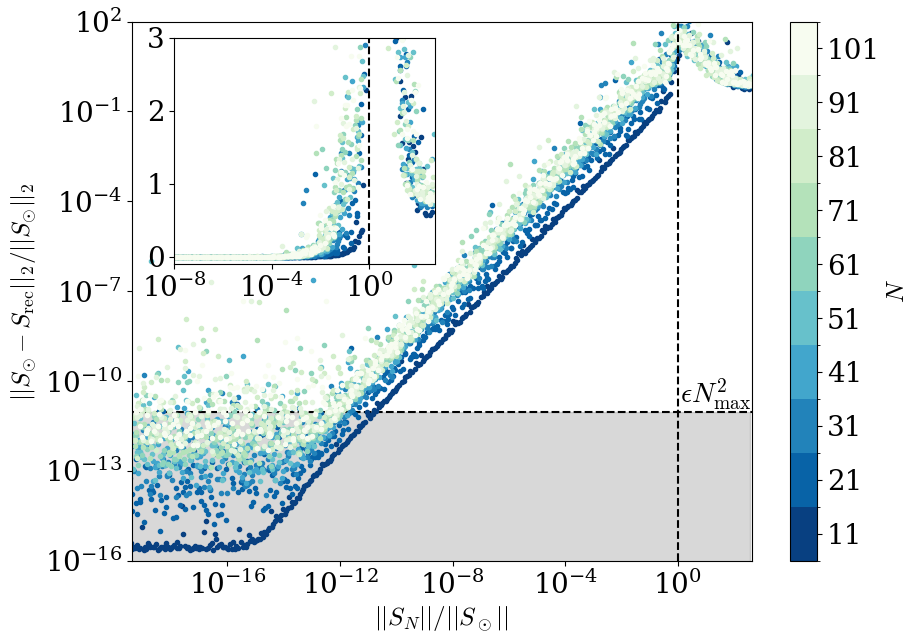

In [5]:
import matplotlib.colors as mcolors
import matplotlib as mpl

col_vec = plt.cm.GnBu_r(np.linspace(0, 1, Nsize))     #"GnBu_r"

# Plot
fig2, ax2 = plt.subplots(1, 1, figsize=(10,7))

#Numerical Precision threshold
col_e='gray'
epsilon = np.finfo(float).eps
print(epsilon)
threshold=((2*Nvec[Nsize-1])**2)*epsilon
pl201u =ax2.fill_between(SN_over_S0_stat_avg[0, :], 
                  y1=threshold*np.ones_like(SN_over_S0_stat_avg[0, :]),
                  y2=np.zeros_like(SN_over_S0_stat_avg[n_md0, :]),
                  edgecolor=col_e,
                  facecolor=col_e,
                  alpha=0.3)   
ax2.axhline(threshold, color='k', linestyle='--')
ax2.text(1.2e0, 2*threshold, '$ \epsilon N_{\\text{max}}^2$')

# Log data plot
for n_md0 in range(Nsize):
    col0= col_vec[n_md0]
    pl202 = ax2.loglog(SN_over_S0_stat_avg[n_md0, :], Er_vs_Srel_stat_avg[n_md0, :],'.', color=col0)
    # pl202 = ax2.loglog(SN_over_S0_stat_avg[n_md0, :], Er_vs_Srel_stat_avg[n_md0, :]/(Nvec[n_md0]**2),'.', color=col0) Normalized by N^2    
ax2.axvline(1, color='k', linestyle='--')


# fig2.colorbar(mpl.cm.ScalarMappable(norm=mpl.colors.Normalize(11, 101), cmap="GnBu_r"),
#              ax=ax2, orientation='vertical', label='$N$')


# --- Minimal fix: discrete colorbar showing only the colors used in the scatter ---
from matplotlib import colors as mcolors
import numpy as np

# col_vec already defined: array of RGBA colors with length Nsize
cmap = mcolors.ListedColormap(col_vec)                  # use the exact colors used in the plot
boundaries = np.linspace(0, Nsize, Nsize+1)             # Nsize discrete bins
norm = mcolors.BoundaryNorm(boundaries, cmap.N)         # map each bin to one color

sm = mpl.cm.ScalarMappable(cmap=cmap, norm=norm)
sm.set_array([])                                        # required for some mpl versions

cbar = fig2.colorbar(sm, ax=ax2, orientation='vertical', label='$N$')
cbar.set_ticks((boundaries[:-1] + boundaries[1:]) / 2)  # place ticks in the center of each color band
cbar.set_ticklabels(Nvec)                               # label ticks with your system sizes


# plt.colorbar(pl202, ax=ax2, cax=Nvec, label='$N$')
ax2.set_xlabel('$||S_N||/||S_\odot||$')
ax2.set_ylabel('$||S_{\odot} - S_{\\text{rec}}||_2 / ||S_{\odot}||_2$')
ax2.set_ylim([1e-16,100])
ax2.set_xlim([4e-20,4.2e2])




lines.append(pl202)

ax2.legend(lines, labels)


# inset Axes....
x1, x2, y1, y2 = 1e-8, 5e2, -0.1, 3e0  # subregion of the original image
axins = ax2.inset_axes(
    [0.069, 0.55, 0.42, 0.42],
    xlim=(x1, x2), ylim=(y1, y2))
for n_md0 in range(Nsize):
    col0= col_vec[n_md0]
    axins.semilogx(SN_over_S0_stat_avg[n_md0, :], Er_vs_Srel_stat_avg[n_md0, :],'.', color=col0)
axins.axvline(1, color='k', linestyle='--')

plt.show()

In [ ]:
#Save Figures
import os

save=False  #False #True
if save==True:
    folder="Figures_InvProblem/"
    if not os.path.isdir(folder):
        os.makedirs(folder)
        print(folder)
    str= time.strftime("%Y-%m-%d_%H_%M_%S")
    filename = "Error_vs_N_{}".format(str)
    filepath = os.path.join(folder, filename)
    fig2.savefig(os.path.join(folder, filename + '.png'), bbox_inches='tight', dpi=300)
    fig2.savefig(os.path.join(folder, filename + '.svg'), bbox_inches='tight')
    fig2.savefig(os.path.join(folder, filename + '.pdf'), bbox_inches='tight')

Figures_InvProblem/
